# Stage 2 — Descriptive Analytics: *What is happening?*
## Objective

This notebook performs the descriptive analytics stage of the Business Analytics lifecycle. The objective is to evaluate the current financial, operational and environmental performance of the University of Greenwich's furniture reuse programme using the validated datasets prepared in Stage 1.

The analysis summarises key performance indicators (KPIs), identifies trends across campuses and furniture categories, and provides an overview of reuse and disposal activities. These findings establish the current operational performance and provide the foundation for the diagnostic, predictive and prescriptive analyses undertaken in the subsequent stages.



In [303]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")
from matplotlib.ticker import StrMethodFormatter

reuse = pd.read_csv("cleaned_reuse.csv")
disposal = pd.read_csv("cleaned_disposal.csv")

## 1. Financial KPIs

This analysis calculates the financial benefits generated through the University's furniture reuse programme. Procurement savings are evaluated using the repurchase cost reference dataset together with the recorded reuse quantities.

Financial indicators, including total procurement savings, average savings per item and replacement values, are calculated. These metrics provide an overview of the economic value created through furniture reuse and establish baseline financial performance for subsequent analyses.




In [304]:
total_savings = reuse["total_cost"].sum()
total_items = reuse["quantity"].sum()
disp_value = disposal["total_value"].sum()

print(f"Total procurement savings : £{total_savings:,.0f}")
print(f"Total items reused        : {total_items:,.0f}")
print(f"Average saving per item   : £{total_savings/total_items:,.2f}")
print(f"Recorded disposal value   : £{disp_value:,.0f}  (partial record)")

Total procurement savings : £230,377
Total items reused        : 1,987
Average saving per item   : £115.94
Recorded disposal value   : £45,418  (partial record)


The reuse programme generated **£230k procurement savings**, demonstrating substantial financial benefits.
- Nearly **2,000 furniture items** were successfully reused.
- Every reused item saved approximately **£116** compared with purchasing new furniture.
- Disposal records are incomplete, therefore disposal value should be interpreted cautiously.


## 2. Operational KPIs — reuse rate by category

This section evaluates the operational performance of the furniture reuse programme by examining reuse activity, disposal observations and furniture movement across campuses.

Operational indicators, including the total number of reused items, recorded disposal observations and campus-level activity, are summarised to assess programme utilisation and operational efficiency.


In [305]:
kpi_cat = pd.DataFrame({
    "items_reused": reuse.groupby("category")["quantity"].sum(),
    "items_disposed_recorded": disposal.groupby("category")["quantity"].sum(),
}).fillna(0)
kpi_cat["reuse_rate_pct"] = (kpi_cat["items_reused"] /
    (kpi_cat["items_reused"] + kpi_cat["items_disposed_recorded"]) * 100)
kpi_cat.round(1)

,items_reused,items_disposed_recorded,reuse_rate_pct
category,,,
Office,475,60,88.8
Seating,1054,267,79.8
Storage,269,40,87.1
Table,189,103,64.7


Office furniture achieved the highest reuse performance.
- Storage furniture also showed excellent recovery.
- Seating contributed the largest reuse volume.
- Tables had the lowest reuse rate, indicating greater disposal.

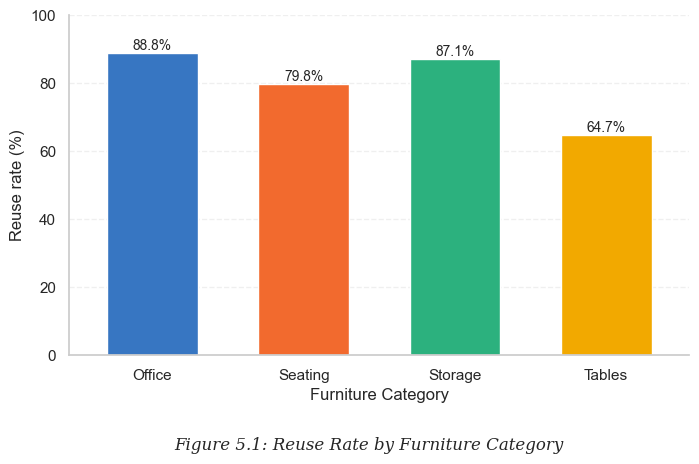

In [306]:
fig, ax = plt.subplots(figsize=(8, 5))

# Rename for display
plot_df = kpi_cat.rename(index={"Table": "Tables"})

plot_df["reuse_rate_pct"].plot(
    kind="bar",
    ax=ax,
    color=["#3776C2", "#F26A2E", "#2CB17E", "#F2A900"],
    width=0.6
)

# Title Caption below figure
fig.text(0.5, 0.01, "Figure 5.1: Reuse Rate by Furniture Category",
    ha="center",
    fontsize=12,
    family="serif",
    style="italic")


# Axis labels
ax.set_ylabel("Reuse rate (%)", fontsize=12)
ax.set_xlabel("Furniture Category", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.grid(axis="x", visible=False)

# Category names
ax.set_xticklabels(plot_df.index, rotation=0, ha="center", fontsize=11)

# Y-axis range
ax.set_ylim(0, 100)



# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add percentage labels
for i, v in enumerate(plot_df["reuse_rate_pct"]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)

# Increase bottom space
plt.subplots_adjust(bottom=0.20)

plt.show()

## 3. Environmental KPIs

This section evaluates the environmental impact of the furniture reuse programme by quantifying carbon emissions avoided and waste diverted from disposal.

Environmental performance is measured using estimated CO₂ emissions and furniture weight associated with reused items. These indicators demonstrate the sustainability benefits generated through extending the useful life of furniture assets.
After Output

In [307]:
print(f"CO2e avoided through reuse : {reuse['total_co2_kg'].sum():,.0f} kg")
print(f"Waste diverted             : {reuse['total_weight_kg'].sum():,.0f} kg")
print(f"Recorded disposal CO2e     : {disposal['total_co2_kg'].sum():,.0f} kg")
print(f"Recorded disposal weight   : {disposal['total_weight_kg'].sum():,.0f} kg")

CO2e avoided through reuse : 82,427 kg
Waste diverted             : 34,867 kg
Recorded disposal CO2e     : 18,389 kg
Recorded disposal weight   : 8,800 kg


- More than **82 tonnes of CO₂ emissions** were avoided through reuse.
- Nearly **35 tonnes of waste** were diverted from landfill.
- Environmental benefits clearly demonstrate the sustainability impact of the reuse programme.

## 4. Campus performance

This analysis compares furniture reuse performance across the Greenwich, Avery Hill and Medway campuses.

Performance measures including procurement savings, reused quantities and environmental benefits are aggregated by campus to identify operational differences and areas of good practice.

In [308]:
campus_kpi = reuse.groupby("campus").agg(
    records=("quantity", "size"), items=("quantity", "sum"),
    savings=("total_cost", "sum"), co2_kg=("total_co2_kg", "sum"),
).sort_values("savings", ascending=False)
campus_kpi["saving_per_item"] = campus_kpi["savings"] / campus_kpi["items"]
display(campus_kpi.round(1))


,records,items,savings,co2_kg,saving_per_item
campus,,,,,
Greenwich,534,1462,160667.8,56438.9,109.9
Avery Hill,151,481,60921.3,22807.0,126.7
Medway,15,44,8788.0,3180.9,199.7


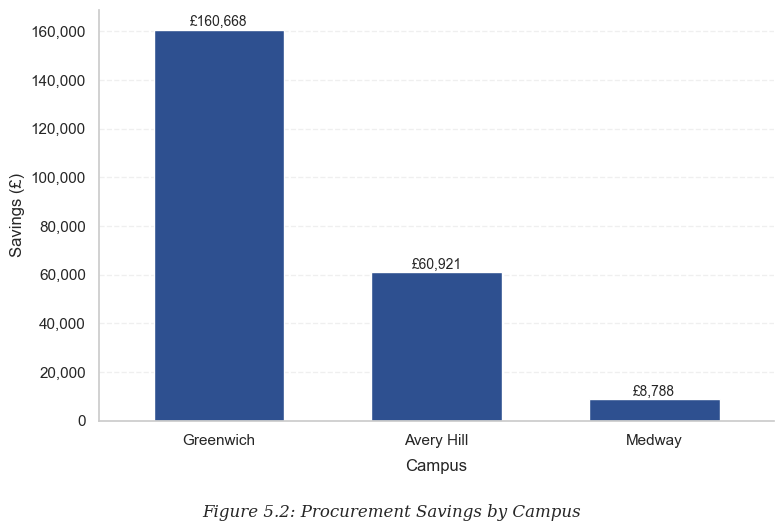

In [309]:
fig, ax = plt.subplots(figsize=(8, 5))
campus_kpi["savings"].plot( kind="bar", ax=ax, color="#2E5090",width=0.6)


# Axis labels
ax.set_ylabel("Savings (£)", fontsize=12)
ax.set_xlabel("Campus", fontsize=12, labelpad=8)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.grid(axis="x", visible=False)
ax.set_xticklabels(campus_kpi.index, rotation=0, ha="center", fontsize=11) # keep

# Format y-axis numbers with commas
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))


# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# Add value labels
for i, v in enumerate(campus_kpi["savings"]):
    ax.text(i, v + max(campus_kpi["savings"]) * 0.01, f"£{v:,.0f}", ha="center", fontsize=10)



# Title caption below figure
fig.text(0.5, -0.05, "Figure 5.2: Procurement Savings by Campus",
    ha="center",
    fontsize=12,
    family="serif",
    style="italic")

# Increase bottom space'
plt.tight_layout()

plt.show()

## 5. Year-on-year trend

This analysis examines how furniture reuse activity has changed over time.

Annual trends are calculated using the recorded reuse dates to evaluate changes in procurement savings, reuse quantities and environmental benefits throughout the study period.

,items,savings
academic_year,,
2020-21,77,6587.0
2021-22,146,14405.0
2022-23,254,22180.0
2023-24,581,75707.0
2024-25,486,73196.0
2025-26,423,36962.0


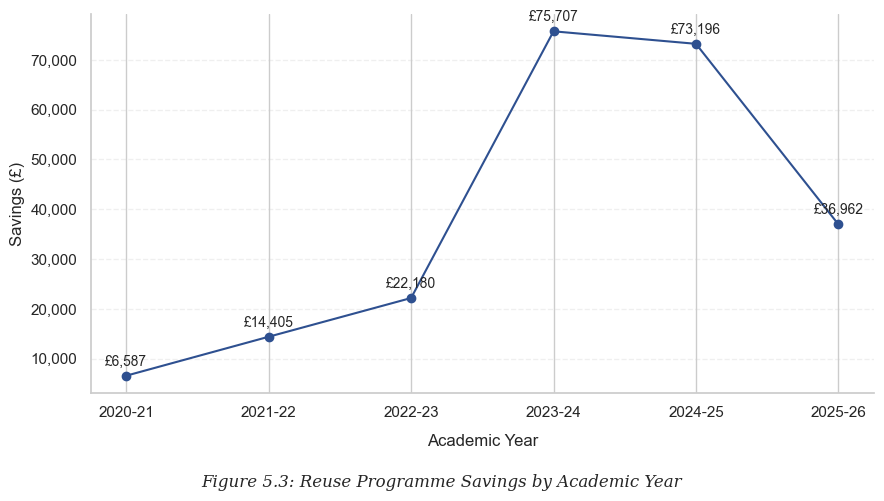

In [317]:
yr = (reuse[reuse["academic_year"] != "Unknown"]
      .groupby("academic_year")
      .agg(items=("quantity", "sum"), savings=("total_cost", "sum")))
display(yr.round(0))


fig, ax = plt.subplots(figsize=(9, 5))
yr["savings"].plot(marker="o", ax=ax, color="#2E5090")

# Add savings value labels
for i, v in enumerate(yr["savings"]):
    ax.text(
        i,                          # x-coordinate
        v + 1500,                   # slightly above the point
        f"£{v:,.0f}",               # format with £ and commas
        ha="center",
        va="bottom",
        fontsize=10)

ax.set_xlabel("Academic Year", fontsize=12, labelpad=10)
ax.set_ylabel("Savings (£)", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Format y-axis numbers with commas
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Title caption below figure
fig.text(0.5, 0.01, "Figure 5.3: Reuse Programme Savings by Academic Year",
    ha="center",
    fontsize=12,
    family="serif",
    style="italic")
  
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout(rect=[0, 0.05, 1, 1]); plt.show()

- Continuous growth occurred from 2020 to 2024 in Reuse Programme Savings by Academic Year.
- Peak savings occurred during **2023–24**.
- Savings declined in 2025–26, likely because the academic year contains incomplete data.


## 6. Recorded disposal by academic year — *new capability*

This section summarises the recorded disposal observations to understand the characteristics of furniture leaving the asset lifecycle.

The disposal dataset is analysed by furniture category, item type and estimated replacement value to identify patterns within the recorded operational observations.
After Output

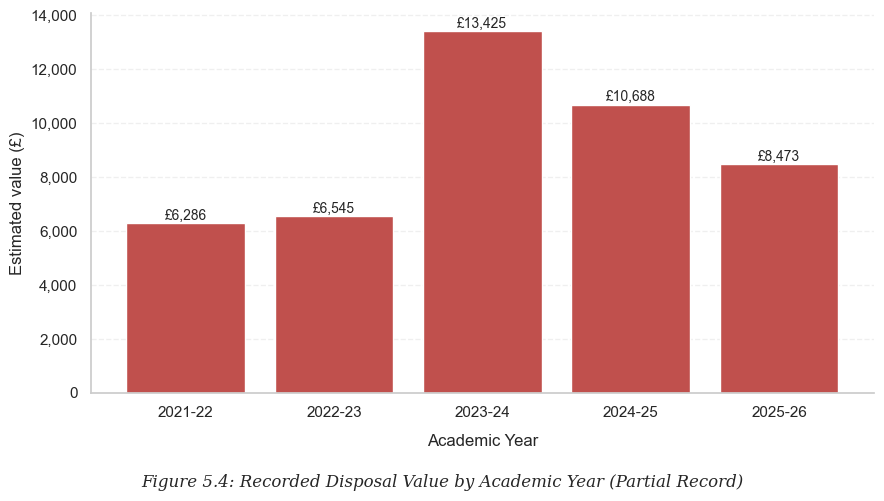

In [318]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(disp_yr.index, disp_yr["value"], color="#C0504D")

# Add value labels
for i, v in enumerate(disp_yr["value"]):
    ax.text(i, v + disp_yr["value"].max() * 0.01,
            f"£{v:,.0f}",
            ha="center",
            fontsize=10)

ax.set_xlabel("Academic Year", fontsize=12, labelpad=10)
ax.set_ylabel("Estimated value (£)", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# Format y-axis numbers with commas
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

fig.text(0.5, 0.01,
    "Figure 5.4: Recorded Disposal Value by Academic Year (Partial Record)",
    ha="center",
    fontsize=12,
    family="serif",
    style="italic")

plt.tight_layout(rect=[0, 0.05, 1, 1]); plt.show()

- Disposal records increased over time.
- Highest disposal value occurred during **2023–24**.
- Since disposal records are partial, increases may reflect improved recording rather than higher disposal.


## 7. Reuse savings vs recorded disposal, by category

The objective of this analysis is to compare the financial value generated through furniture reuse with the estimated replacement value of recorded disposal observations across each furniture category. This comparison provides an overview of how effectively different categories contribute to procurement savings while identifying categories where valuable furniture continues to be recorded for disposal.

The total procurement savings from the Furniture Reuse Register are aggregated by furniture category and compared with the estimated replacement value recorded in the Disposal Observation List. The comparison is presented using a grouped visualisation to highlight differences between the financial benefits achieved through reuse and the potential value lost through recorded disposal.

This analysis uses the recorded disposal dataset as an operational reference and does not estimate the University's total disposal activity, recognising that the disposal observations represent only a partial record.

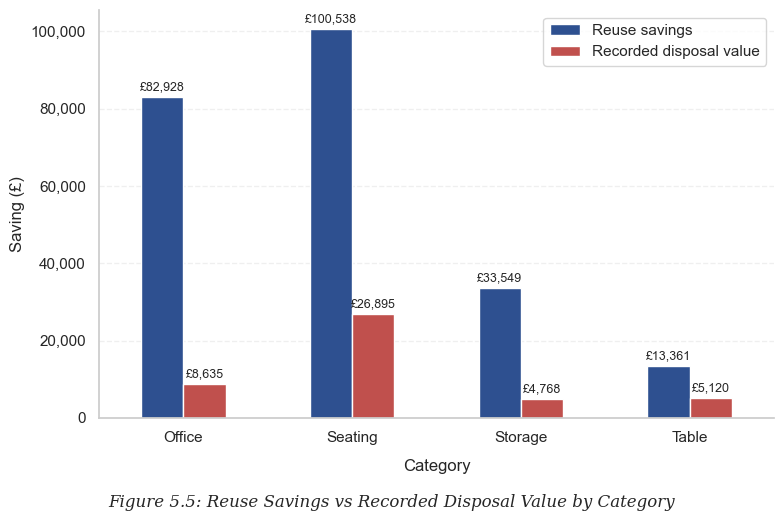

In [312]:
fig, ax = plt.subplots(figsize=(8, 5))

cat_compare.plot(
    kind="bar",
    ax=ax,
    color=["#2E5090", "#C0504D"])

# Display values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="£{:,.0f}",
        padding=3,
        fontsize=9)
# Labels
ax.set_xlabel("Category", fontsize=12, labelpad=10)
ax.set_ylabel("Saving (£)", fontsize=12)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.grid(axis="x", visible=False)

# Remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# Format y-axis numbers with commas
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))


# X-axis labels
plt.xticks(rotation=0)

# Figure caption at the bottom
fig.text(
    0.5, -0.03,
    "Figure 5.5: Reuse Savings vs Recorded Disposal Value by Category",
    ha="center",
    fontsize=12,
    family="serif",
    style="italic"
)

plt.tight_layout()
plt.show()

The comparison illustrates the balance between procurement savings achieved through furniture reuse and the estimated financial value of furniture recorded for disposal within each category. Categories demonstrating high procurement savings together with relatively low recorded disposal values indicate effective reuse practices and stronger asset utilisation.
                                                                                                                                                                                                                                      
- Reuse savings substantially exceeded disposal value across all categories.
- Seating generated the highest financial benefit.
- Tables contributed comparatively lower savings.

## 8. Top item types and condition 

The objective of this analysis is to identify the furniture item types that contribute most significantly to the University's furniture reuse programme and to examine the condition profile of reused assets. Understanding which furniture types are most frequently reused and generate the highest procurement savings provides insight into asset utilisation patterns and highlights opportunities to maximise financial and environmental benefits.

The Furniture Reuse Register is grouped by item type to calculate the total quantity of reused items and the associated procurement savings. The analysis ranks item types according to reuse frequency and financial contribution. In addition, the distribution of furniture condition grades is examined to evaluate the quality of assets entering the reuse programme.

In [313]:
# Top 10 item types by procurement savings
top_items = (
    reuse.assign(item=reuse["item_type"].str.strip().str.title())
    .groupby("item")
    .agg(
        qty=("quantity", "sum"),
        savings=("total_cost", "sum"))
    .sort_values("savings", ascending=False)
    .head(10))

display(top_items.round(0))



,qty,savings
item,,
Desk,301,68154.0
Chair,648,44439.0
Operator Chair,430,42698.0
Sofa,42,17294.0
Pedestal,100,10002.0
Table,129,9023.0
Cupboard,27,5673.0
Bookcase,36,5134.0
Coffee Table,65,4923.0


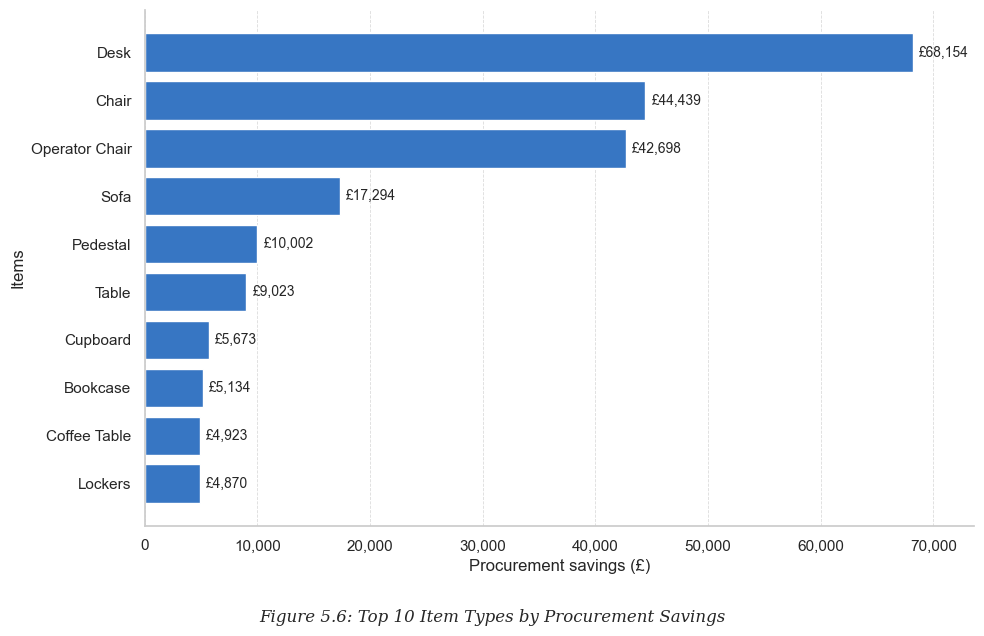

In [322]:
# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal bar chart
bars = ax.barh(top_items.index, top_items["savings"], color="#3776C3")

# Largest value at the top
ax.invert_yaxis()

# Axis labels
ax.set_xlabel("Procurement savings (£)", fontsize=12)
ax.set_ylabel("Items", fontsize=12)

# Increase tick label size
ax.tick_params(axis="both", labelsize=11)

# Light vertical grid lines
ax.grid(axis="x", linestyle="--", linewidth=0.6, color="lightgray", alpha=0.8)
ax.grid(axis="y", visible=False)

# Format x-axis numbers with commas
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Add a little space to the right for value labels
ax.margins(x=0.08)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add value labels
offset = top_items["savings"].max() * 0.008

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + offset,
        bar.get_y() + bar.get_height() / 2,
        f"£{width:,.0f}",
        va="center",
        ha="left",
        fontsize=10)

# Figure caption below chart
fig.text( 0.5, -0.05,
    "Figure 5.6: Top 10 Item Types by Procurement Savings",
    ha="center", fontsize=12, family="serif", style="italic")

plt.tight_layout()
plt.show()

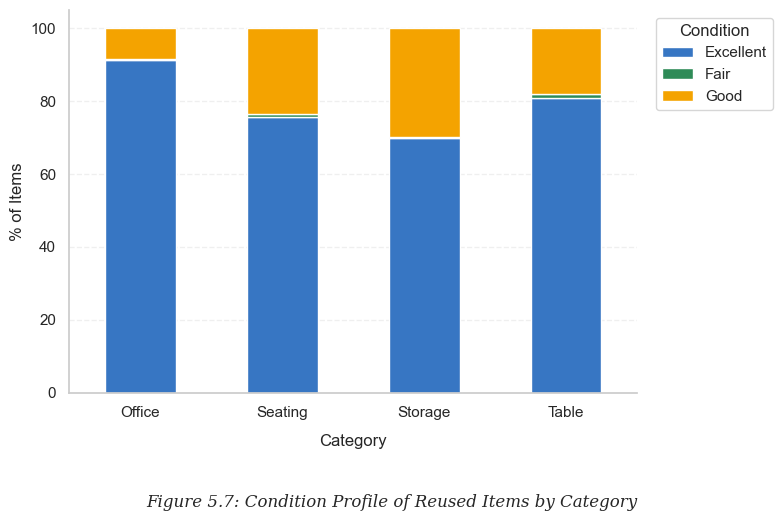

In [315]:
fig, ax = plt.subplots(figsize=(8, 5))

(cond.div(cond.sum(axis=1), axis=0) * 100).plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#3776C3", "#2E8B57", "#F4A300"])

# Axis labels
ax.set_xlabel("Category", fontsize=12, labelpad=10)
ax.set_ylabel("% of Items", fontsize=12)

# Keep category names horizontal
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Horizontal gridlines only
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.grid(axis="x", visible=False)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(title="Condition", bbox_to_anchor=(1.02, 1), loc="upper left")

# Figure caption
fig.text( 0.5, -0.03, "Figure 5.7: Condition Profile of Reused Items by Category",
    ha="center", fontsize=12, family="serif", style="italic")

# Leave room for the caption
plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.show()

- Desks produced the largest financial savings.
- Chairs represented the highest reuse volume.
- Office furniture dominates both quantity and financial impact.

From Condition profile 
- Most reused furniture is in **Good** or **Excellent** condition.
- Limited numbers of poor-condition items entered the reuse programme.
- This indicates effective quality control before redistribution.

# Overall Findings

## Financial Impact
- £230,377 procurement savings
- £115.94 average saving per reused item

## Operational Performance
- 1,987 items successfully reused
- Office and Storage categories achieved the highest reuse rates

## Environmental Impact
- 82,427 kg CO₂ emissions avoided
- 34,867 kg waste diverted

## Campus Performance
- Greenwich dominates total reuse activity
- Medway achieves highest savings per item

## Trend Analysis
- Reuse programme expanded rapidly until 2023–24.
- Slight decline during 2025–26 likely reflects incomplete yearly data rather than reduced programme effectiveness.

## Overall Conclusion

The descriptive analytics demonstrates that the furniture reuse programme delivers strong financial savings, high operational efficiency, and substantial environmental benefits. The results indicate that reuse is an effective strategy for reducing procurement costs, minimising waste, and supporting sustainability objectives across the university.